In [1]:
# ================================
# STEP 1: Import Libraries
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# ================================
# STEP 2: Load Dataset (CSV)
# ================================
df = pd.read_csv("/content/titanic.csv")   # Make sure file is in same folder

print("First 5 rows:")
print(df.head())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [4]:
# ================================
# STEP 3: Data Cleaning
# ================================
# Select useful columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# Rename target column (business understanding)
df.rename(columns={'Survived': 'Converted'}, inplace=True)

# Handle missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)

print("\nAfter Cleaning:")
print(df.head())





After Cleaning:
   Converted  Pclass     Sex   Age     Fare
0          0       3    male  22.0   7.2500
1          1       1  female  38.0  71.2833
2          1       3  female  26.0   7.9250
3          1       1  female  35.0  53.1000
4          0       3    male  35.0   8.0500


/tmp/ipykernel_2902/1604592682.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [5]:
# ================================
# STEP 4: Convert Categorical Data
# ================================
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])   # male=1, female=0



In [6]:
# ================================
# STEP 5: Features & Target
# ================================
X = df.drop('Converted', axis=1)
y = df['Converted']



In [7]:
# ================================
# STEP 6: Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
# ================================
# STEP 7: Model Building
# ================================
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [9]:
# ================================
# STEP 8: Prediction
# ================================
y_pred = model.predict(X_test)


In [10]:
# ================================
# STEP 9: Evaluation
# ================================
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)



Model Accuracy: 0.7988826815642458

Confusion Matrix:
 [[89 16]
 [20 54]]


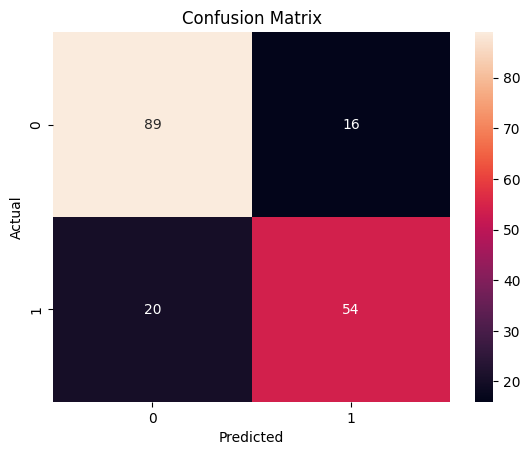

In [11]:
# ================================
# STEP 10: Visualization
# ================================
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()